In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import math
from cycler import cycler

# Define high-contrast color palette
# 1. Deep Blue, 2. Brick Red, 3. Forest Green, 4. Muted Purple, 5. Safety Orange, 
# 6. Chestnut Brown, 7. Raspberry Pink, 8. Slate Gray, 9. Olive Gold, 10. Teal/Cyan

general_colors = ['#1f77b4','#d62728','#2ca02c','#9467bd','#ff7f0e','#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf' ]
light_colors = ['#0047AB',  '#FF0000',  '#00CC00',  '#9932CC',  '#FF8C00',  '#FF00FF',  '#FFD700',  '#00CED1',  '#FF4500',  '#7FFF00']

# General graph settings
plt.rcParams.update({
    # Font settings
    'font.family': 'sans-serif',          # Universal font family
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'], # Fallback fonts
    # 'font.family': 'serif',          # Cambiato da sans-serif a serif
    # 'font.serif': ['Computer Modern', 'Times New Roman', 'DejaVu Serif'], # Lista di font serif
    'mathtext.fontset': 'cm',        # Imposta i simboli matematici nello stile di LaTeX (Computer Modern
    # 'mathtext.fontset': 'stix',           # Makes LaTeX math symbols match the text font style
    
    # Color cycle settings
    'axes.prop_cycle': cycler(color=light_colors), # Sets the default color sequence for multiple lines
    
    # Size and resolution
    # 'axes.titleweight' : 'bold',
    'figure.titleweight' : 'bold',
    'font.size': 14,                      # General font size
    'axes.labelsize': 14,                 # Size of axis labels (x, y)
    'axes.titlesize': 16,                 # Size of the plot title
    'legend.fontsize': 12,                # Legend font size
    
    # Line and marker aesthetics
    'lines.linewidth': 2,                 # Line width
    'lines.markersize': 5,                # Marker size
    'figure.figsize': (10, 6),            # Default figure size
    
    # Grid settings
    'axes.grid': True,                    # Enable grid by default
    'grid.alpha': 0.4,                    # Make grid slightly transparent
    'grid.linestyle': '--',               # Dashed grid style
    'errorbar.capsize': False             # Add caps to error bars
})

# Exercise 12


### MNIST with Keras

The goal of exercise 12 is to use deep neural network models, implemented in the Keras python package, to recognize and distinguish between the ten handwritten digits (0-9).

The MNIST dataset comprises $70000$ handwritten digits, each of which comes in a square image, divided into a $28\times 28$ pixel grid. Every pixel can take on $256$ gradation of the gray color, interpolating between white and black, and hence each data point assumes any value in the set $\{0,1,\dots,255\}$. Since there are $10$ categories in the problem, corresponding to the ten digits, this problem represents a generic **classification task**. 

### Exercise 12.1

Change at will and train your DNN by increasing the number of epochs to an adeuqate value. Try to use at least two other optimizers, different from SGD: watch to accuracy and loss for training and validation data and comment on the performances.

In [3]:
import tensorflow as tf
from tensorflow import keras
import os

from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects
from tensorflow.keras.models import load_model

import json

seed=0
np.random.seed(seed) # fix random seed
tf.random.set_seed(seed)

Import MNIST data

In [4]:
from keras.datasets import mnist

# input image dimensions
img_rows, img_cols = 28, 28 # number of pixels 
# output
num_classes = 10 # 10 digits

# the data, split between train and test sets
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

print(X_test.shape)

(10000, 28, 28)


Reshape of data, convert to float, rescale, example of data and label

an example of a data point with label 4


<Figure size 800x500 with 0 Axes>

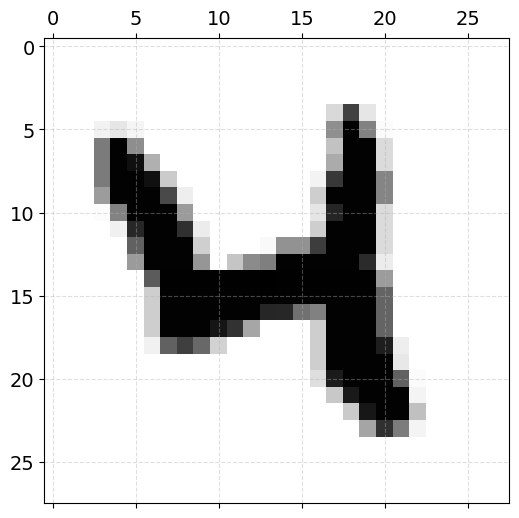

... and with label [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.] after to_categorical


In [5]:
X_train = X_train.reshape(X_train.shape[0], img_rows*img_cols)
X_test = X_test.reshape(X_test.shape[0], img_rows*img_cols)

# cast to floats
X_train = X_train.astype('float32')     #Trasformo i dati in float32
X_test = X_test.astype('float32')

# rescale data in interval [0,1]
X_train /= 255      #Lo riscalo tra 0 e 1
X_test /= 255

plt.figure(figsize=(8, 5))
# look at an example of data point
print('an example of a data point with label', Y_train[20])
# matshow: display a matrix in a new figure window
plt.matshow(X_train[20,:].reshape(28,28),cmap='binary')
plt.show()

# convert class vectors to binary class matrices, e.g. for use with categorical_crossentropy
Y_train = keras.utils.to_categorical(Y_train, num_classes)
Y_test = keras.utils.to_categorical(Y_test, num_classes)
print('... and with label', Y_train[20], 'after to_categorical')


I create DNN

In [6]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input

def create_DNN():
    # instantiate model
    model = Sequential()
    model.add(Input(shape=(img_rows*img_cols,)))
    # add a dense all-to-all relu layer
    model.add(Dense(400, activation='relu'))        # I can change functions
    # add a dense all-to-all relu layer
    model.add(Dense(100, activation='relu'))
    # apply dropout with rate 0.5
    model.add(Dropout(0.5))
    # soft-max layer
    model.add(Dense(num_classes, activation='softmax'))
    
    return model

print('Model architecture created successfully!')

optimizer_list = [ 'SGD', 'Adam','RMSprop']

Model architecture created successfully!


I define a new compiling function, with a new dictionary of different optimizers.

I used the libraries ´SDG´, ´Adam´ and ´RMSprop´ since they seem to be the most used in the field.

**WARNING**

**This is the actual training loop, that will take many minutes to run on a laptop.**
Be careful in using it. Anyway, while this training code saves the model on "SAVED_MODEL" folder, the previously trained model (50 epochs) were saved in "SAVED_MODELS_50epochs", thus they are safe from accidental new training. 

In [7]:
from keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Adam, Adamax, Nadam 

def compile_model(optimizer):
    model = create_DNN()
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=optimizer,
                  metrics=['acc'])
    return model

# optimizer_list = [ 'SGD', 'Adam','RMSprop']

optimizer_dict = {
    optimizer_list[0]: SGD(),
    optimizer_list[1]: Adam(),
    optimizer_list[2]: RMSprop(),
    # 'Adagrad': Adagrad()
}

print('Model compiled successfully, now I can do the loop on the optimizers.')

# training parameters
training_history = {}
batch_size = 32     # Ogni gruppo mi da un gradiente impreciso
epochs = 50          # DA AUMENTARE FINCHE SCENDE LA LOSS

for opt_name, opt_object in optimizer_dict.items():
    # create the deep neural net
    print('Compiling and training DNN using', opt_name, '...')
    model_DNN = compile_model(opt_object)

    # train DNN and store training info in history
    history = model_DNN.fit(X_train, Y_train,
            batch_size=batch_size,
            epochs=epochs,
            shuffle=True, # a good idea is to shuffle input before at each epoch
            verbose=1,
            validation_data=(X_test, Y_test))
    training_history[opt_name] = history

    model_DNN.save(f"SAVED_MODELS/sequential_DNN_model_{opt_name}.keras")
    print(f"Saved model as sequential_DNN_model_{opt_name}.keras in SAVED_MODELS")

    with open(f'SAVED_MODELS/sequential_DNN_model_{opt_name}.json', 'w') as f:
        json.dump(history.history, f)


E0000 00:00:1781436968.463580  109103 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model compiled successfully, now I can do the loop on the optimizers.
Compiling and training DNN using SGD ...
Epoch 1/50


W0000 00:00:1781436969.348957  109103 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - acc: 0.7768 - loss: 0.7623 - val_acc: 0.9140 - val_loss: 0.3178
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.8904 - loss: 0.3882 - val_acc: 0.9314 - val_loss: 0.2408
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - acc: 0.9123 - loss: 0.3136 - val_acc: 0.9402 - val_loss: 0.2026
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9248 - loss: 0.2676 - val_acc: 0.9464 - val_loss: 0.1766
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.9330 - loss: 0.2373 - val_acc: 0.9499 - val_loss: 0.1612
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - acc: 0.9419 - loss: 0.2112 - val_acc: 0.9547 - val_loss: 0.1459
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.9463 - loss: 0.1914 - val_acc: 0.9584 - val_loss: 0.1335
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - acc: 0.9499 - loss: 0.1770 - val_acc: 0.9618 - val_loss: 0.1248
Epoch 9/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1

W0000 00:00:1781437600.321964  109103 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - acc: 0.9175 - loss: 0.2819 - val_acc: 0.9664 - val_loss: 0.1067
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - acc: 0.9645 - loss: 0.1216 - val_acc: 0.9709 - val_loss: 0.0941
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - acc: 0.9753 - loss: 0.0855 - val_acc: 0.9758 - val_loss: 0.0786
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - acc: 0.9800 - loss: 0.0675 - val_acc: 0.9766 - val_loss: 0.0830
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - acc: 0.9838 - loss: 0.0532 - val_acc: 0.9790 - val_loss: 0.0780
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - acc: 0.9857 - loss: 0.0456 - val_acc: 0.9786 - val_loss: 0.0852
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - acc: 0.9875 - loss: 0.0396 - val_acc: 0.9808 - val_loss: 0.0864
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - acc: 0.9890 - loss: 0.0343 - val_acc: 0.9782 - val_loss: 0.0942
Epoch 9/50
1875/1875 ━━━━━━━━━━━━━━━

W0000 00:00:1781438567.465531  109103 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - acc: 0.9202 - loss: 0.2767 - val_acc: 0.9693 - val_loss: 0.1177
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - acc: 0.9630 - loss: 0.1414 - val_acc: 0.9721 - val_loss: 0.1091
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - acc: 0.9698 - loss: 0.1247 - val_acc: 0.9705 - val_loss: 0.1525
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - acc: 0.9732 - loss: 0.1189 - val_acc: 0.9749 - val_loss: 0.1498
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - acc: 0.9741 - loss: 0.1152 - val_acc: 0.9738 - val_loss: 0.1494
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - acc: 0.9758 - loss: 0.1068 - val_acc: 0.9746 - val_loss: 0.1282
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 9ms/step - acc: 0.9774 - loss: 0.1067 - val_acc: 0.9748 - val_loss: 0.1623
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - acc: 0.9784 - loss: 0.1071 - val_acc: 0.9753 - val_loss: 0.1676
Epoch 9/50
1875/1875 ━━━━━━━━━━━━━━━━

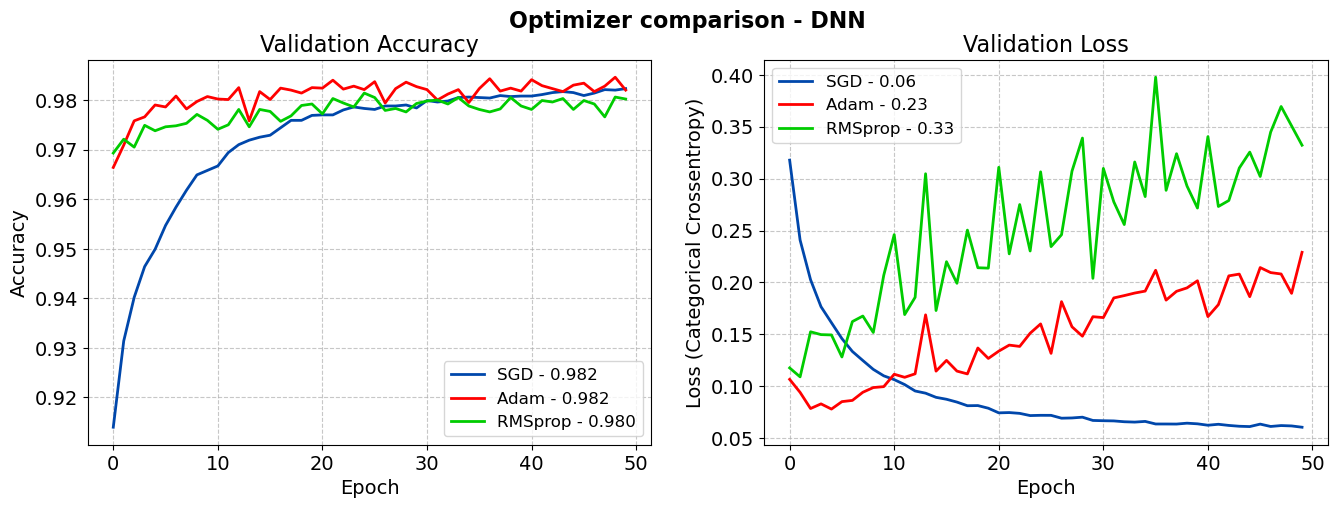

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Optimizer comparison - DNN", fontsize=16)

# accuracy
for opt_name in optimizer_list:
    with open(f'SAVED_MODELS_50epochs/sequential_DNN_model_{opt_name}.json', 'r') as f:
        history_data = json.load(f)
    final_acc = history_data['val_acc'][-1]
    ax1.plot(history_data['val_acc'], label=f'{opt_name} - {final_acc:.3f}', linewidth=2)
ax1.set_title('Validation Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(loc='best')
ax1.grid(True, linestyle='--', alpha=0.7)

# loss
for opt_name in optimizer_list:
    with open(f'SAVED_MODELS_50epochs/sequential_DNN_model_{opt_name}.json', 'r') as f:
        history_data = json.load(f)
    final_loss = history_data['val_loss'][-1]
    ax2.plot(history_data['val_loss'], label=f'{opt_name} - {final_loss:.2f}', linewidth=2)
ax2.set_title('Validation Loss')
ax2.set_ylabel('Loss (Categorical Crossentropy)')
ax2.set_xlabel('Epoch')
ax2.legend(loc='best')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.show()

E0000 00:00:1781457543.119668  143528 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


(10000, 784)


W0000 00:00:1781457545.650399  143528 cpu_allocator_impl.cc:82] Allocation of 31360000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
(10000, 784)
(10000, 28, 28, 1)


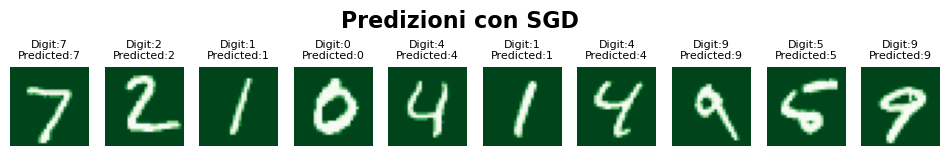

(10000, 784)
 13/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step  

W0000 00:00:1781457550.207449  143528 cpu_allocator_impl.cc:82] Allocation of 31360000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
(10000, 784)
(10000, 28, 28, 1)


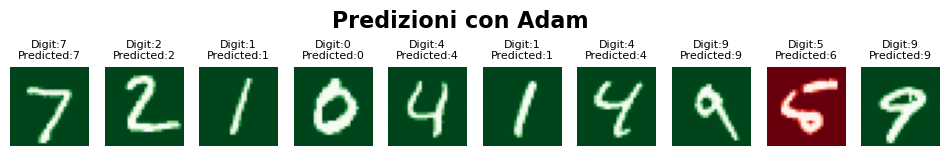

(10000, 784)
 14/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step  

W0000 00:00:1781457553.858372  143528 cpu_allocator_impl.cc:82] Allocation of 31360000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
(10000, 784)
(10000, 28, 28, 1)


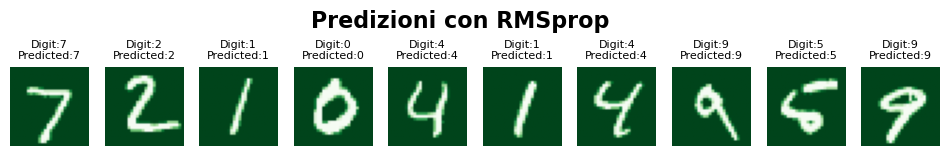

In [11]:
for opt_name in optimizer_list:
    model_DNN = load_model(f"SAVED_MODELS_50epochs/sequential_DNN_model_{opt_name}.keras")

    X_test = X_test.reshape(X_test.shape[0], img_rows*img_cols)

    print(X_test.shape)

    predictions = model_DNN.predict(X_test)

    print(X_test.shape)

    X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols,1)

    print(X_test.shape)

    plt.figure(figsize=(12,2)) 
    plt.suptitle(f"Predizioni con {opt_name}", fontsize=16)
    for i in range(10):    
        ax = plt.subplot(1, 10, i + 1)
        digit = format(np.argmax(Y_test[i]))
        predicted = format(np.argmax(predictions[i]))
        if digit == predicted :
            plt.imshow(X_test[i, :, :, 0], cmap='Greens_r')
        else: plt.imshow(X_test[i, :, :, 0], cmap='Reds_r')

        plt.title(f"Digit:{digit}\nPredicted:{predicted}", fontsize=8)
        # plt.title("Digit: {}\nPredicted:    {}".format(np.argmax(Y_test[i]), np.argmax(predictions[i])), fontsize=6)
        plt.axis('off')
        # plt.tight_layout()
    plt.show()

The SDG algorithm is the best among the three chosen.

#### Creating Convolutional Neural Nets with Keras

We have so far considered each MNIST data sample as a $(28\times 28,)$-long 1d vector. On the other hand, we do know that in every one of the hand-written digits there are *local* spatial correlations between the pixels, but also *translational invariance*, which we would like to take advantage of to improve the accuracy of our classification model. To this end, we first need to reshape the training and test input data as follows

In [7]:
# you will need the following for Convolutional Neural Networks
from keras.layers import Flatten, Conv2D, MaxPooling2D          # Da keras importo i layers

print('X_train shape:', X_train.shape)
print('Y_train shape:', Y_train.shape)
print()
print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

# reshape data, depending on Keras backend
if keras.backend.image_data_format() == 'channels_first':                   # Qua dipende da che keras uso
    X_train = X_train.reshape(X_train.shape[0], 1, img_rows, img_cols)
    X_test = X_test.reshape(X_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    X_train = X_train.reshape(X_train.shape[0], img_rows, img_cols, 1)
    X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)

print('X_train shape:', X_train.shape)
print('Y_train shape:', Y_train.shape)
print()
print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

X_train shape: (60000, 784)
Y_train shape: (60000, 10)

60000 train samples
10000 test samples
X_train shape: (60000, 28, 28, 1)
Y_train shape: (60000, 10)

60000 train samples
10000 test samples


One can ask the question of whether a neural net can learn to recognize such local patterns. This can be achieved by using convolutional layers.

## Exercise 12.2
### Assignment

Change the architecture of your DNN using convolutional layers. Use `Conv2D`, `MaxPooling2D`, `Dropout`, but also do not forget `Flatten`, a standard `Dense` layer and `soft-max` in the end. I have merged step 2 and 3 in the following definition of `create_CNN()` that **you should complete**.

### Solution
I completed the model with:
- A max pool layer with a (2, 2) pool_size and a (2, 2) strideto downsize the first layer output.
- A second convolutional layer (Conv2D) with 20 filters, a (3, 3) kernel size, and a ReLU activation function.
- Another max pool layer with a (2, 2) pool_size but with a (1, 1) stride and 'same' padding, so that I have an output matrix size equal to the input.
- A flatten layer to collapse the 2D/3D feature maps into a single 1D vector.
- A dense hidden layer with 64 neurons and a ReLU activation function.
- A second dense hidden layer with 32 neurons and a ReLU activation function.
- A dropout layer with a rate of 0.5, which randomly turns off 50% of the neurons during training to prevent overfitting.
- A final dense output layer with 10 neurons and a softmax activation function to output the final probability.


In [8]:
def create_CNN(optimizer):
    # instantiate model
    model = Sequential()
    # add first convolutional layer with 10 filters (dimensionality of output space)
    model.add(Conv2D(10, kernel_size=(5, 5),
                     activation='relu',
                     input_shape=input_shape))

    # MaxPool
    model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
    # Another conv
    model.add(Conv2D(20, kernel_size=(3, 3), activation='relu'))
    # MaxPool
    model.add(MaxPooling2D(pool_size=(2, 2), strides=(1, 1), padding='same'))
    # Appiattisco i dati
    model.add(Flatten())
    # Aggiungo neuroni
    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))
    # Aggiungo dropout
    model.add(Dropout(0.5))
    # Output layer
    model.add(Dense(num_classes, activation='softmax'))

    # compile the model
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=optimizer,
                  metrics=['acc'])
    return model

Train your DCNN and evaluate its performance proceeding exactly as before:

In [10]:
from keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Adam, Adamax, Nadam 

optimizer_list = [ 'SGD', 'Adam','RMSprop']

optimizer_dict = {
    optimizer_list[0]: SGD(),
    optimizer_list[1]: Adam(),
    optimizer_list[2]: RMSprop(),
    # 'Adagrad': Adagrad()
}

# training parameters
training_history = {}
batch_size = 32     
epochs = 15         # INSERT HERE AN ADEQUATE NUMBER OF EPOCHS!

for opt_name, opt_object in optimizer_dict.items():

    print('Compiling and training CNN using', opt_name, '...')

    # create the deep conv net
    model_CNN=create_CNN(opt_object)

    # train CNN
    history = model_CNN.fit(X_train, Y_train,
            batch_size=batch_size,
            epochs=epochs,
            shuffle=True,
            verbose=1,
            validation_data=(X_test, Y_test))
    training_history[opt_name] = history

    # evaliate model
    score = model_CNN.evaluate(X_test, Y_test, verbose=1)

    # print performance
    print()
    print('Test loss:', score[0])
    print('Test accuracy:', score[1])

    model_CNN.save(f"SAVED_MODELS/CNN_model_{opt_name}.keras")
    print(f"Saved model as CNN_model_{opt_name}.keras in SAVED_MODELS")

    with open(f'SAVED_MODELS/CNN_model_{opt_name}.json', 'w') as f:
        json.dump(history.history, f)

Compiling and training CNN using SGD ...
Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - acc: 0.6957 - loss: 0.8786 - val_acc: 0.9562 - val_loss: 0.1668
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - acc: 0.8980 - loss: 0.3295 - val_acc: 0.9724 - val_loss: 0.0943
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - acc: 0.9288 - loss: 0.2310 - val_acc: 0.9791 - val_loss: 0.0685
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - acc: 0.9427 - loss: 0.1850 - val_acc: 0.9827 - val_loss: 0.0575
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - acc: 0.9503 - loss: 0.1583 - val_acc: 0.9843 - val_loss: 0.0480
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - acc: 0.9550 - loss: 0.1449 - val_acc: 0.9842 - val_loss: 0.0480
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - acc: 0.9593 - loss: 0.1290 - val_acc: 0.9867 - val_loss: 0.0403
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - acc: 0.9627 - loss: 0.1183 - val_acc: 0.9873 - 

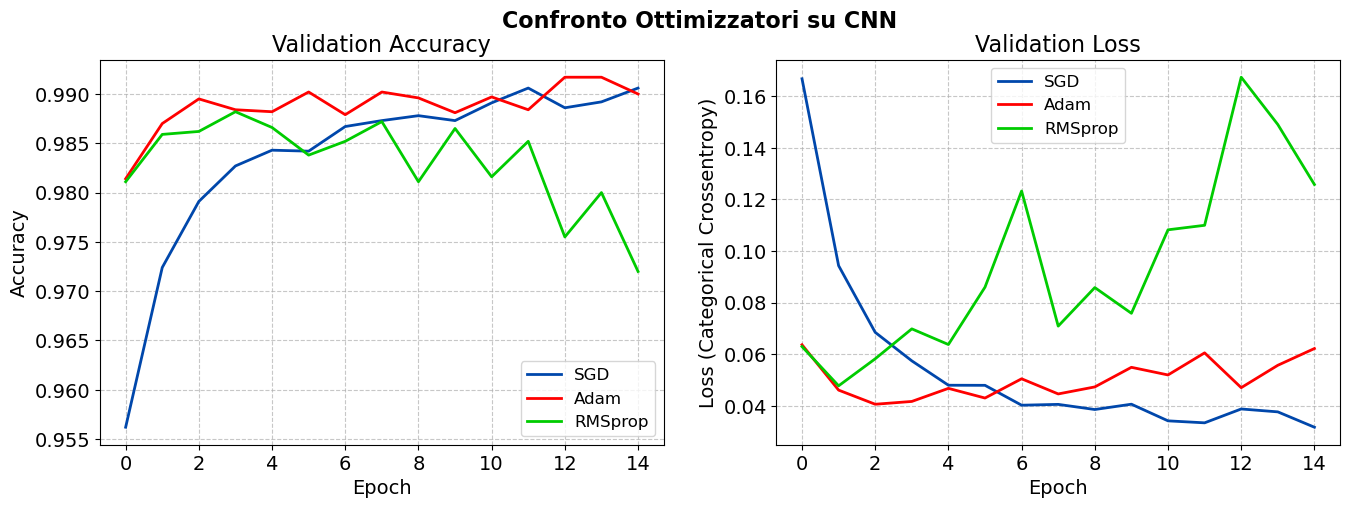

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Confronto Ottimizzatori su CNN", fontsize=16)

# accuracy
for opt_name in optimizer_list:
    with open(f'SAVED_MODELS_15epochs/CNN_model_{opt_name}.json', 'r') as f:
        history_data = json.load(f)
    ax1.plot(history_data['val_acc'], label=opt_name, linewidth=2)
ax1.set_title('Validation Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(loc='best')
ax1.grid(True, linestyle='--', alpha=0.7)

# loss
for opt_name in optimizer_list:
    with open(f'SAVED_MODELS_15epochs/CNN_model_{opt_name}.json', 'r') as f:
        history_data = json.load(f)
    ax2.plot(history_data['val_loss'], label=opt_name, linewidth=2)
ax2.set_title('Validation Loss')
ax2.set_ylabel('Loss (Categorical Crossentropy)')
ax2.set_xlabel('Epoch')
ax2.legend(loc='best')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.show()

### Exercise 12.3

Use the `gimp` application to create 10 pictures of your "handwritten" digits, import them in your jupyter-notebook and try to see if your CNN is able to recognize your handwritten digits.

For example, you can use the following code to import a picture of an handwritten digit
(Note: you should install Python Image Library (PIL/Pillow):

(10, 28, 28)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step


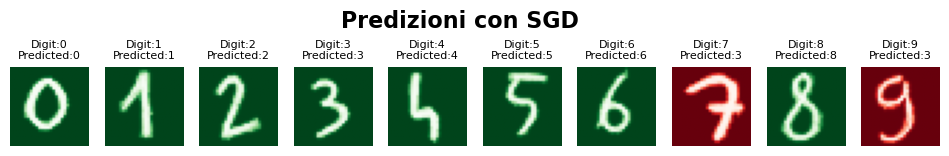

(10, 28, 28)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step


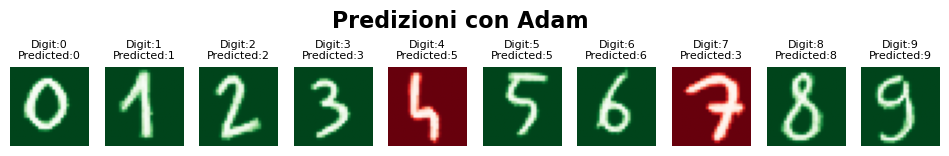

(10, 28, 28)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


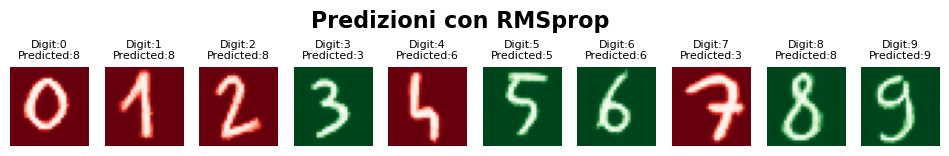

In [13]:
from PIL import Image
import os

images_list = []
ydim=0
xdim = 0

# Loading images in a list
for k in range(num_classes):
    digit_filename = f"digits/{k}.png"
    digit_in = Image.open(digit_filename).convert('L')

    ydim, xdim = digit_in.size
    
    # Trasformiamo l'immagine in un array NumPy (mantiene già la forma corretta Altezza x Larghezza)
    digit_array = np.array(digit_in)
    images_list.append(digit_array)

# Convert the list in a NumPy array
# shape: (10, altezza, larghezza)
data = np.array(images_list)

# Trasforma l'array in float prima di dividere
data = data.astype('float32') 
data /= 255.0


# Carico i vari modelli
for opt_name in optimizer_list:
    model_CNN = load_model(f"SAVED_MODELS_15epochs/CNN_model_{opt_name}.keras")

    # Qui salvo i valori predetti
    prediction = np.zeros(num_classes)

    #data = data.reshape(data, 1)
    # data = data[0]
    print(data.shape)
    

    prediction = model_CNN.predict(data)

    # data = data.reshape(data.shape[0], xdim, ydim)

########

    plt.figure(figsize=(12,2))

    plt.suptitle(f"Predizioni con {opt_name}", fontsize=16)

    for i in range(num_classes):    
        ax = plt.subplot(1, num_classes, i + 1)
        digit = i
        predicted = np.argmax(prediction[i])
        if digit == predicted : 
            plt.imshow(data[i, :, :], cmap='Greens_r')    
        else: plt.imshow(data[i, :, :], cmap='Reds_r')

        plt.title(f"Digit:{digit}\nPredicted:{predicted}", fontsize=8)    
        #plt.title("Digit: {}\nPredicted:    {}".format(np.argmax(Y_test[i]), np.argmax(predictions[i])), fontsize=6)  
        plt.axis('off') 
        #plt.tight_layout()
    plt.show()

Also in this case, the best optimizer is SDG, that in 15 generations gets to a accuracy=0.99. This optimizer predicts correctly 9/10 digits. Then comes Adam, with a similar result but a bad looking loss function, that guesses 8/10 digits. Lastly, the RMSprop algorithm performs quite badly, and his accuracy decreases sensibily after only 3-5 generations. This sign of overfitting is also reflected in the 5/10 digits predicted.

In [15]:
from keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Adam, Adamax, Nadam 

optimizer_list = ['RMSprop']

optimizer_dict = {
    optimizer_list[0]: RMSprop()
}

# training parameters
training_history = {}
batch_size = 32     
epochs = 5

for opt_name, opt_object in optimizer_dict.items():

    print('Compiling and training CNN using', opt_name, '...')

    # create the deep conv net
    model_CNN=create_CNN(opt_object)

    # train CNN
    history = model_CNN.fit(X_train, Y_train,
            batch_size=batch_size,
            epochs=epochs,
            shuffle=True,
            verbose=1,
            validation_data=(X_test, Y_test))
    training_history[opt_name] = history

    # evaliate model
    score = model_CNN.evaluate(X_test, Y_test, verbose=1)

    # print performance
    print()
    print('Test loss:', score[0])
    print('Test accuracy:', score[1])

    model_CNN.save(f"SAVED_MODELS_5epochs/CNN_model_{opt_name}.keras")
    print(f"Saved model as CNN_model_{opt_name}.keras in SAVED_MODELS_5epochs")

    with open(f'SAVED_MODELS_5epochs/CNN_model_{opt_name}.json', 'w') as f:
        json.dump(history.history, f)

Compiling and training CNN using RMSprop ...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - acc: 0.8885 - loss: 0.3603 - val_acc: 0.9830 - val_loss: 0.0657
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - acc: 0.9614 - loss: 0.1395 - val_acc: 0.9884 - val_loss: 0.0409
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - acc: 0.9695 - loss: 0.1111 - val_acc: 0.9881 - val_loss: 0.0471
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - acc: 0.9724 - loss: 0.1037 - val_acc: 0.9872 - val_loss: 0.0547
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - acc: 0.9727 - loss: 0.1046 - val_acc: 0.9871 - val_loss: 0.0542
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - acc: 0.9871 - loss: 0.0542

Test loss: 0.054178692400455475
Test accuracy: 0.9871000051498413
Saved model as CNN_model_RMSprop.keras in SAVED_MODELS_5epochs


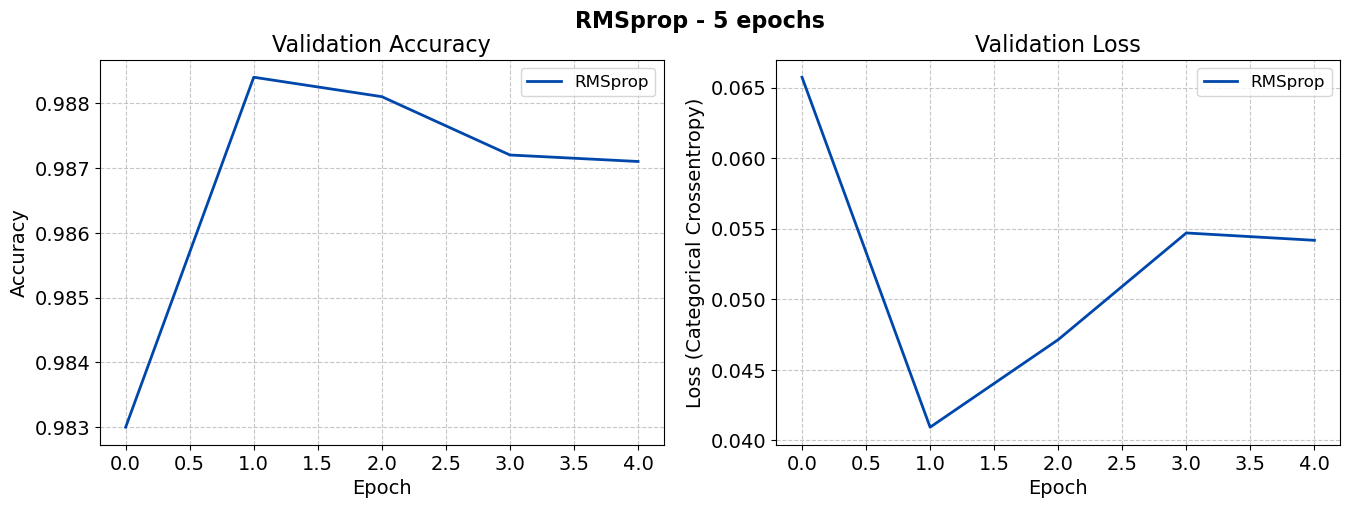

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("RMSprop - 5 epochs", fontsize=16)

optimizer_list = ['RMSprop']

# accuracy
for opt_name in optimizer_list:
    with open(f'SAVED_MODELS_5epochs/CNN_model_{opt_name}.json', 'r') as f:
        history_data = json.load(f)
    ax1.plot(history_data['val_acc'], label=opt_name, linewidth=2)
ax1.set_title('Validation Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(loc='best')
ax1.grid(True, linestyle='--', alpha=0.7)

# loss
for opt_name in optimizer_list:
    with open(f'SAVED_MODELS_5epochs/CNN_model_{opt_name}.json', 'r') as f:
        history_data = json.load(f)
    ax2.plot(history_data['val_loss'], label=opt_name, linewidth=2)
ax2.set_title('Validation Loss')
ax2.set_ylabel('Loss (Categorical Crossentropy)')
ax2.set_xlabel('Epoch')
ax2.legend(loc='best')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.show()

(10, 28, 28)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step


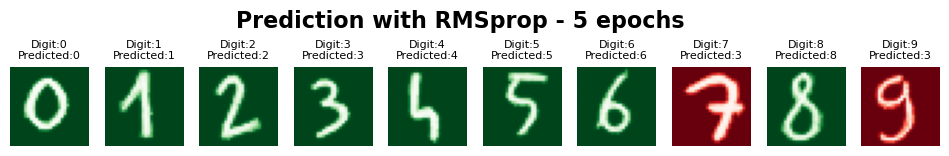

In [20]:
from PIL import Image
import os

images_list = []
ydim=0
xdim = 0

# Loading images in a list
for k in range(num_classes):
    digit_filename = f"digits/{k}.png"
    digit_in = Image.open(digit_filename).convert('L')

    ydim, xdim = digit_in.size
    
    # Trasformiamo l'immagine in un array NumPy (mantiene già la forma corretta Altezza x Larghezza)
    digit_array = np.array(digit_in)
    images_list.append(digit_array)

# Convert the list in a NumPy array
# shape: (10, altezza, larghezza)
data = np.array(images_list)

# Trasforma l'array in float prima di dividere
data = data.astype('float32') 
data /= 255.0


optimizer_list = ['RMSprop']

# Carico i vari modelli
for opt_name in optimizer_list:
    model_CNN = load_model(f"SAVED_MODELS_5epochs/CNN_model_{opt_name}.keras")

    # Qui salvo i valori predetti
    prediction = np.zeros(num_classes)

    #data = data.reshape(data, 1)
    # data = data[0]
    print(data.shape)
    

    prediction = model_CNN.predict(data)

    # data = data.reshape(data.shape[0], xdim, ydim)

########

    plt.figure(figsize=(12,2))

    plt.suptitle(f"Prediction with {opt_name} - 5 epochs", fontsize=16)

    for i in range(num_classes):    
        ax = plt.subplot(1, num_classes, i + 1)
        digit = i
        predicted = np.argmax(prediction[i])
        if digit == predicted : 
            plt.imshow(data[i, :, :], cmap='Greens_r')    
        else: plt.imshow(data[i, :, :], cmap='Reds_r')

        plt.title(f"Digit:{digit}\nPredicted:{predicted}", fontsize=8)    
        #plt.title("Digit: {}\nPredicted:    {}".format(np.argmax(Y_test[i]), np.argmax(predictions[i])), fontsize=6)  
        plt.axis('off') 
        #plt.tight_layout()
    plt.show()

A smaller number of epochs reduces overfitting and gets a better result.